In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
#matplotlib==3.10.0
#numpy==2.2.1
#pandas==2.2.3
#requests==2.32.3
#scikit-learn==1.6.0
#scipy==1.14.1
#seaborn==0.13.2
#statsmodels==0.14.4
#tqdm==4.67.1

In [1]:
import tmdbdata as td
import genderprediction as gp 

import requests
import pandas as pd
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import random
import ast
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import norm
from itertools import combinations

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.decomposition import PCA

# Mise en contexte

Il est dimanche soir, assis sur son canapé, Jean allume son ordinateur et se connecte à son site de streaming préféré. Après avoir refusé quelques publicités et pop-ups douteux, une myriade de films se proposent à lui. Face à un tel embarras du choix, entre les Tuches 7 et The Dark Knight, Jean hésite... . 

C'est que sur ce site il n'y a pas toutes les informations qu'il voudrait avoir. Certes, il a la date de sortie des films, leur synopsis ou encore leur durée, mais quid de leur qualité, ou de leur genre? 

Au fond, il doit bien y avoir des indices qui permettent d'inférer sur la qualité ou sur certaines propriétés d'un film. 

**Que peut-on dire d'un film sans l'avoir vu?**

Ni une ni deux, Jean se met à coder!

# Présentation générale du projet 

## Les données

Pour ce projet, nous avons décidé de travailler avec deux sources de données:

- The Movie Database (TMDB), qui comme son nom l'indique est une base de données sur le cinéma mondial (et les séries). Il dispose d'une API gratuite, fonctionnelle et facile d'utilisation.
- Data.gouv.fr et en particulier son fichier Lieux de tournage à Paris 

## Le Plan

**I - Récupération des données et statistiques descriptives**

A - Récupération et traitement des données

B - Statistiques descriptives

**II - Prédire la note d'un film à l'aide de l'économétrie** 

A - Première régression

B- Prédiction optimale

**III - Prédire le genre d'un film à l'aide de forêts aléatoires**

A - Que donne une ACP sur le genre?

B - Prédire le genre grâce à des Forêts Aléatoires

**IV - L'influence du lieu de tournage sur les caractéristiques d'un film**

# I - Récupération des données et statistiques descriptives

## A - Récupération et traitement des données

Dans cette partie on ne s'intéresse qu'aux données issues de TMDB. 

La majorité des fonctions permettant de récolter les données et de les traiter se trouvent dans le code tmdbdata (td), nous les appellerons à plusieurs reprises dans ce Notebook.

Nous utilisons deux méthodes de l'API de TMDB:  "Discover Movies" et "Movies Details". La première nous permet de récolter rapidement de l'information sur des films en fonction de certains filtres et selon un certain classement. Malheureusement, cette méthode ne permet pas de récolter toute l'information disponible pour chaque film: elle ne capture par exemple ni le budget ni le revenu du film. C'est la deuxième méthode qui le permet: à partir de l'identifiant TMDB d'un film, elle renvoie toutes les informations disponibles sur ce film. 

La récolte des données se fait donc toujours en deux temps. Dans un premier temps on récupère les identifiants des films qui nous intéressent pour notre modèle grâce à Discover movies. Puis pour chaque identifiant on récolte les données spécifiques du film en question grâce à "Movie Details".

Pour cette première partie, on va prendre comme échantillon, les films en anglais les plus notés (avec le plus d'avis laissés par les utilisateurs) sur TMDB. 


In [4]:
ids= td.get_movie_ids_list(1, headers=td.headers) # tire la première page des films US les plus notés, il y a 20 films par page.
df=td.get_movies_info(ids,headers=td.headers)

getting movie ids


100%|██████████| 1/1 [00:00<00:00,  1.93it/s]


getting movie info


100%|██████████| 20/20 [00:02<00:00,  7.05it/s]


En remplaçant 1 par 20, on récupère les 400 films contenus dans usbestmovies. 

In [5]:
df=pd.read_csv("usbestmovies.csv")

On récupère un data-frame avec beaucoup de données inutiles pour notre analyse et pas nécessairement très lisible, on va donc le nettoyer à l'aide de différentes fonctions: on se débarasse des données inutiles, on recode la date de sortie et le genre...

In [ ]:
df.head(2)

,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,imdb_id,origin_country,original_language,...,status,tagline,title,video,vote_average,vote_count,belongs_to_collection.id,belongs_to_collection.name,belongs_to_collection.poster_path,belongs_to_collection.backdrop_path
0,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,NaN,160000000,"[{'id': 28, 'name': 'Action'}, {'id': 878, 'na...",https://www.warnerbros.com/movies/inception,27205,tt1375666,"['US', 'GB']",en,...,Released,Your mind is the scene of the crime.,Inception,False,8.37,36731,NaN,NaN,NaN,NaN
1,False,/9REO1DLpmwhrBJY3mYW5eVxkXFM.jpg,NaN,165000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 18, '...",http://www.interstellarmovie.net/,157336,tt0816692,['US'],en,...,Released,Mankind was born on Earth. It was never meant ...,Interstellar,False,8.40,35892,NaN,NaN,NaN,NaN


In [7]:
df=td.clean_data(df) #nettoyage général des données
df.head(2)

,budget,id,overview,popularity,release_date,revenue,runtime,title,vote_average,vote_count,main_genre_id,main_genre_name,full_poster_path,overview_count,title_count,timestamp
0,160000000,27205,"Cobb, a skilled thief who commits corporate es...",117.816,2010-07-15,825532764,148,Inception,8.37,36731,28,Action,https://image.tmdb.org/t/p/original//oYuLEt3zV...,280,9,1279152000
1,165000000,157336,The adventures of a group of explorers who mak...,258.255,2014-11-05,701729206,169,Interstellar,8.40,35892,12,Adventure,https://image.tmdb.org/t/p/original//gEU2QniE6...,198,12,1415145600


## B - Statistiques descriptives

Pour cette partie, on va encore simplifier notre data-frame.

En explorant les données on se rend compte que beaucoup de films n'ont pas d'information quant à leur budget ou leur revenu (affiché comme étant 0). On décide donc de remplacer ces 0 par la moyenne des films dont on connaît cette information

In [8]:
df["revenue"] = df["revenue"].replace(0, df["revenue"][df["revenue"] != 0].mean())
df["budget"] = df["budget"].replace(0, df["budget"][df["budget"] != 0].mean())
#df["revenue"] = np.log(df["revenue"])
#df["budget"] = np.log(df["budget"])

Enfin, pour le modèle économétrique qui suivra bientôt on encode la colonne "main_genre_name" par la méthode : "One hot encoding".
De plus on ne garde dans cette partie que les données suivante: genre, id, vote moyen, budget, durée, longueur du synopsis, revenu.

In [9]:
genre_columns=[]
for genre in df["main_genre_name"].unique() :
    df["main_genre_name"+"_"+str(genre)] = (df["main_genre_name"] == genre).astype(int) 
    genre_columns.append("main_genre_name"+"_"+str(genre))
var_explicative=["id","vote_average","budget","runtime","overview_count","revenue"]
var_explicative.extend(genre_columns)
df=df.loc[:,var_explicative]
df.head(2)

,id,vote_average,budget,runtime,overview_count,revenue,main_genre_name_Action,main_genre_name_Adventure,main_genre_name_Drama,main_genre_name_Science Fiction,...,main_genre_name_Animation,main_genre_name_Fantasy,main_genre_name_Family,main_genre_name_Horror,main_genre_name_Mystery,main_genre_name_Western,main_genre_name_History,main_genre_name_Music,main_genre_name_War,main_genre_name_Romance
0,27205,8.37,160000000.0,148,280,825532764.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,157336,8.40,165000000.0,169,198,701729206.0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


On commence par étudier la dispersion des variables.

In [10]:
df.describe()

,id,vote_average,budget,runtime,overview_count,revenue,main_genre_name_Action,main_genre_name_Adventure,main_genre_name_Drama,main_genre_name_Science Fiction,...,main_genre_name_Animation,main_genre_name_Fantasy,main_genre_name_Family,main_genre_name_Horror,main_genre_name_Mystery,main_genre_name_Western,main_genre_name_History,main_genre_name_Music,main_genre_name_War,main_genre_name_Romance
count,400.000000,400.000000,4.000000e+02,400.000000,400.000000,4.000000e+02,400.000000,400.000000,400.000000,400.000000,...,400.000000,400.000000,400.00000,400.00000,400.000000,400.0000,400.0000,400.000000,400.000000,400.000000
mean,129510.180000,7.466062,1.027915e+08,125.272500,292.262500,5.384871e+08,0.275000,0.167500,0.150000,0.060000,...,0.072500,0.047500,0.02500,0.02500,0.015000,0.0025,0.0025,0.005000,0.010000,0.020000
std,167714.533441,0.603830,7.950942e+07,23.109161,132.497084,4.247439e+08,0.447073,0.373889,0.357519,0.237784,...,0.259639,0.212972,0.15632,0.15632,0.121705,0.0500,0.0500,0.070622,0.099623,0.140175
min,11.000000,5.785000,8.069470e+05,76.000000,58.000000,2.859750e+06,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.00000,0.000000,0.0000,0.0000,0.000000,0.000000,0.000000
25%,770.500000,7.038750,3.000000e+07,108.750000,184.750000,2.449317e+08,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.00000,0.000000,0.0000,0.0000,0.000000,0.000000,0.000000
50%,46607.000000,7.496500,9.000000e+07,123.000000,280.000000,4.483672e+08,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.00000,0.000000,0.0000,0.0000,0.000000,0.000000,0.000000
75%,262653.750000,7.915250,1.540000e+08,137.000000,370.250000,7.507392e+08,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.00000,0.000000,0.0000,0.0000,0.000000,0.000000,0.000000
max,872585.000000,8.708000,4.600000e+08,242.000000,902.000000,2.923706e+09,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.00000,1.00000,1.000000,1.0000,1.0000,1.000000,1.000000,1.000000


On peut ensuite voir comment nos variables sont corrélées entre elles (pour le genre on prend l'exemple des drames) 

/tmp/ipykernel_152026/534337137.py:1: DeprecationWarning: bias and ddof have no effect and are deprecated
  corr = np.corrcoef(df.loc[:, ["vote_average", "budget", "runtime", "overview_count", "revenue", "main_genre_name_Drama"]].T, bias=True)


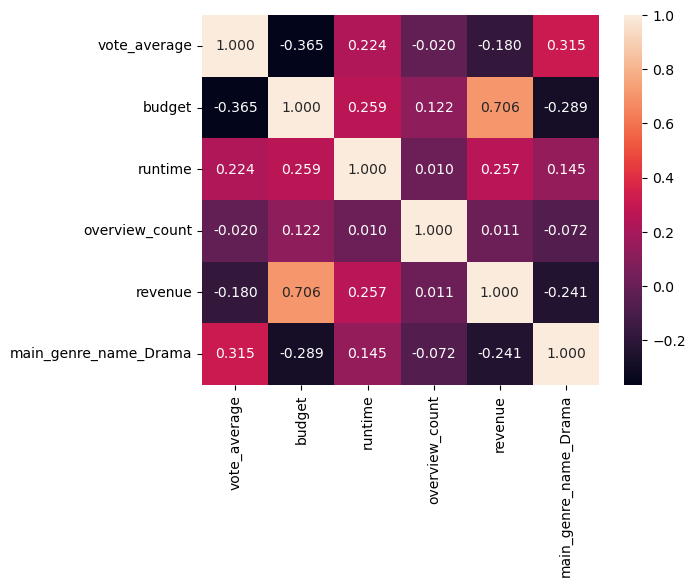

In [ ]:
corr = np.corrcoef(df.loc[:, ["vote_average", "budget", "runtime", "overview_count", "revenue", "main_genre_name_Drama"]].T, bias=True)

labs = ['vote_average', 'budget', 'runtime', 'overview_count', 'revenue', 'main_genre_name_Drama']

sns.heatmap(corr, annot=True, fmt='.3f', xticklabels=labs, yticklabels=labs)

plt.show()

On a des résultats qui sont pour certains attendus : corrélation proche de 1 pour le revenu et pour le budget. D'autres qui sont plus surprenants, en particulier budget et note moyenne sont négativement corrélés.

On peut visualiser cette corrélation négative surprenante grâce à un nuage de points. On peut aussi visualiser la faible corrélation entre notes et longueur du film de la même manière.

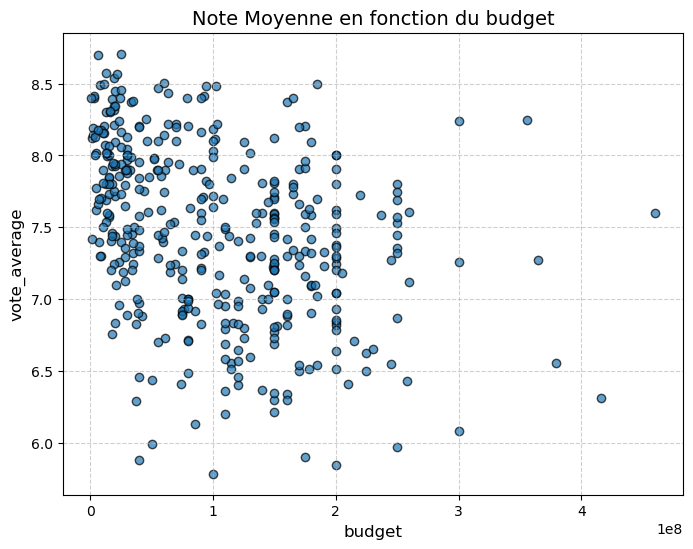

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(df['budget'], df['vote_average'], alpha=0.7, edgecolor='k')

plt.title("Note Moyenne en fonction du budget", fontsize=14)
plt.xlabel("budget", fontsize=12)
plt.ylabel("vote_average", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

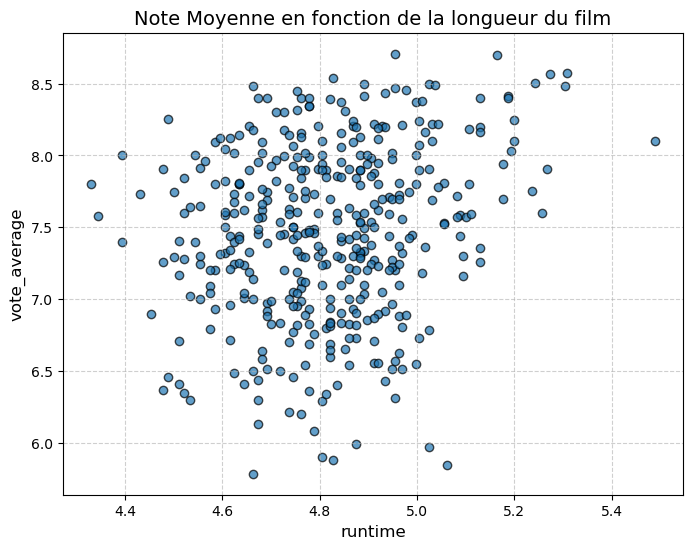

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(np.log(df['runtime']), df['vote_average'], alpha=0.7, edgecolor='k')

plt.title("Note Moyenne en fonction de la longueur du film", fontsize=14)
plt.xlabel("runtime", fontsize=12)
plt.ylabel("vote_average", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Même si on a pas une droite parfaite qui apparaît, cette corrélation nous permet d'établie qu'une régression linéaire de la note moyenne sur les données est pertinente. 

Enfin, on peut regarder comment se répartissent les genres de film dans nos données.

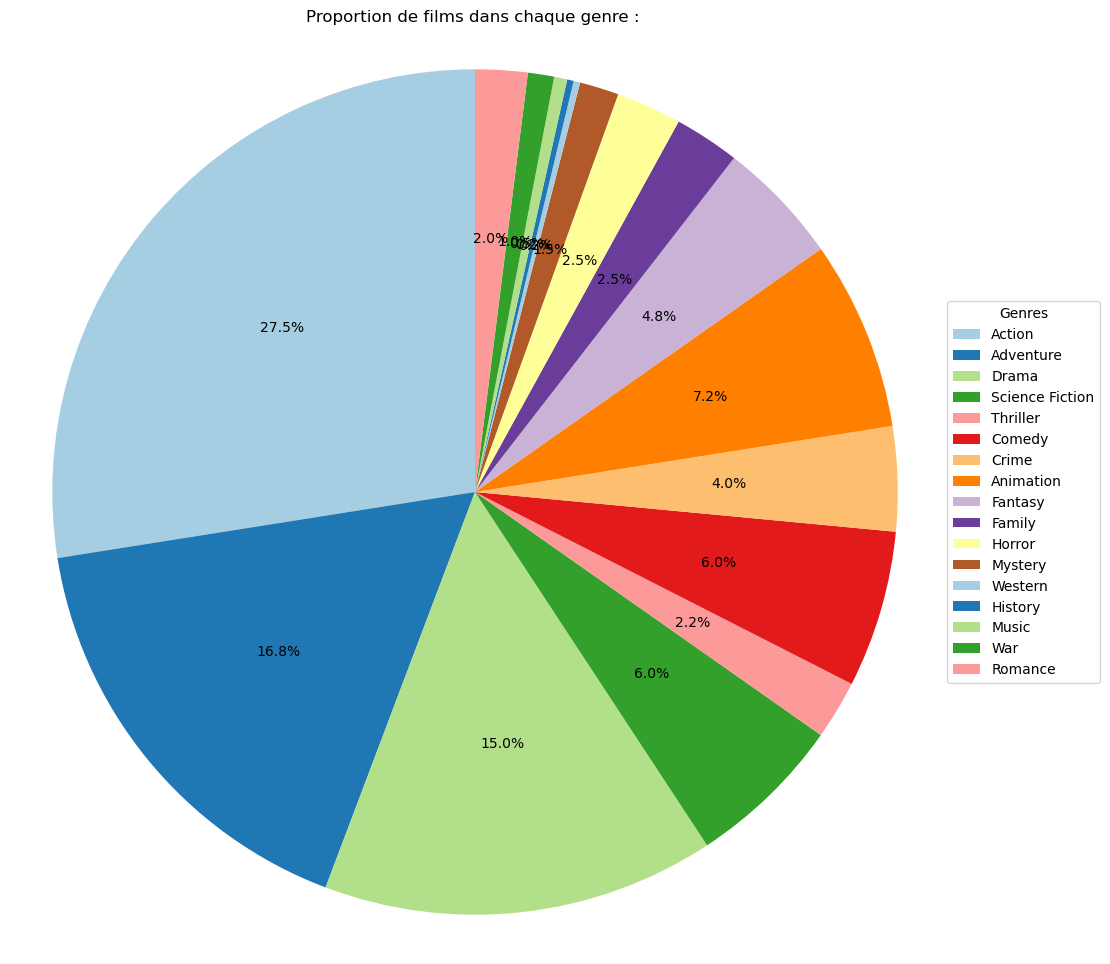

In [14]:
genre_counts = df[genre_columns].sum()
genre_proportions = genre_counts / genre_counts.sum()
genre_labels = [genre.split("main_genre_name_")[1] for genre in genre_proportions.index]
plt.figure(figsize=(12,12))
wedges, texts, autotexts = plt.pie(genre_proportions, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

plt.legend(wedges, genre_labels, title="Genres", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title('Proportion de films dans chaque genre : ')
plt.axis('equal')  
plt.show()

On constate que certains genres sont clairement plus présents que d'autres dans nos données, en particulier les films d'action, d'aventure et les drames. C'est plutôt cohérent avec le fait que ce jeu de données soit essentiellement composé de block-busters holywoodiens. 

# II - Prédire la note d'un film à l'aide de l'économétrie

On cherche maintenant à prédire la note moyenne d'un film à partir des autres données. Pour cela nous appliquons les notions d'économétrie que nous avons vues en cours ce semestre.
On garde le même data-frame "df" que précédemment.

NB : La normalisation et la standardisation des données n'est pas nécessaire dans la regression linéaire. En effet, contrairement au modèle de clustering, la regression linéaire ne sélectionne pas les covariables par leurs poids. 

## A - Première régression

On réalise une première régression linéaire sur nos données (hors ID).

In [15]:
X=df.loc[:,~df.columns.isin(['id', 'vote_average']) ] #données explicatives
Y=df[["vote_average"]] #variable d'intérêt

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2,random_state=42) # 80% de notre échantillon est utilisé pour estimer les coefs de la regression linéaire 

# Initialiser le modèle de régression linéaire
model = LinearRegression()

# Entraîner le modèle avec l'ensemble d'entraînement
model.fit(X_train, Y_train)

# Prédire les résultats sur l'ensemble de test
Y_pred = model.predict(X_test)

# Afficher les coefficients de la régression linéaire
print("Variables de la régression linéaire: ", df.columns[2:] )
print("Coefficients de la régression linéaire :", model.coef_)
print("Ordonnée à l'origine (intercept) :", model.intercept_)

# Évaluer la performance du modèle
mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Erreur quadratique moyenne (MSE) : {mse}")
print(f"Erreur absolue moyenne (MAE) : {mae}")
print(f"Score R2 : {r2}")

Variables de la régression linéaire:  Index(['budget', 'runtime', 'overview_count', 'revenue',
       'main_genre_name_Action', 'main_genre_name_Adventure',
       'main_genre_name_Drama', 'main_genre_name_Science Fiction',
       'main_genre_name_Thriller', 'main_genre_name_Comedy',
       'main_genre_name_Crime', 'main_genre_name_Animation',
       'main_genre_name_Fantasy', 'main_genre_name_Family',
       'main_genre_name_Horror', 'main_genre_name_Mystery',
       'main_genre_name_Western', 'main_genre_name_History',
       'main_genre_name_Music', 'main_genre_name_War',
       'main_genre_name_Romance'],
      dtype='object')
Coefficients de la régression linéaire : [[-3.47191760e-09  1.00467868e-02  3.21678318e-04  1.75886077e-10
  -3.15919748e-01 -1.73506371e-01  2.00993592e-01 -2.19129692e-01
  -3.11557486e-01 -1.68768825e-02  1.43006865e-01  4.46786889e-01
  -3.93967619e-02 -2.20042830e-01 -1.44739533e-01  2.29252040e-01
   1.38777878e-17  3.23528638e-01 -1.63461881e-01  1.440

Quelques interpretations : 
Le coef des MCO devant la variable "budget" peut s'interpreter comme suit : chaque million de dollars supplémentaires réduit la note moyenne d'environ 0.0033.
Le coef des MCO devant la variable "runtime" peut s'interpreter comme suit : une augmentation de 10 minutes dans la durée d'un film est associée à une augmentation de 0.101 dans la variable dépendante "vote_average"

Remarque : les coefficients devant les covariables budget, revenue, ect ... Sont relativement petit comparé aux coefficients devant le genre car par ex la variable budget prend des valeurs très grandes.  

Distinguer les covariables ayant réellement un impact sur Y : (tests multiples de niveau 5%, rejet de H0 à tort au niv 5%) 

In [16]:
# Ajouter une constante à X pour inclure l'intercept dans le modèle
X = sm.add_constant(X)

# Créer le modèle de régression linéaire
model = sm.OLS(Y, X).fit()  # OLS = Ordinary Least Squares (régression linéaire)

# Obtenir les résultats du modèle
summary = model.summary()

# Afficher le résumé qui contient les statistiques t de chaque covariable
print(summary)

                            OLS Regression Results                            
Dep. Variable:           vote_average   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                     11.08
Date:                Sun, 29 Dec 2024   Prob (F-statistic):           1.91e-27
Time:                        15:46:37   Log-Likelihood:                -273.19
No. Observations:                 400   AIC:                             588.4
Df Residuals:                     379   BIC:                             672.2
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

La différence de R2 entre statmodel et sklearn vient du fait qu'on entraine nos données sur 100% des données sur statmodel vs 80% sur sklearn. Notons que les statistiques de test, sont en valeur absolu relativement élevés ce qui signifie qu'elles sont significatives. 


In [17]:
#Zone de rejet de niveau 5% pour notre test d'hypothèse (H0: B0 =0) :
var_non_significative_au_niv_5=[] 
quant = norm.ppf(1-5/200, loc=0, scale=1)
for var in X.columns:
    if  model.tvalues[var] >= quant or model.tvalues[var] <= - quant : 
        print("On rejette H0, ie que la covariable ", var, "a un impact sur la variable vote_average, ",var," est significative au niveau 5%")
    else: 
        var_non_significative_au_niv_5.append(var)
print(var_non_significative_au_niv_5)


On rejette H0, ie que la covariable  const a un impact sur la variable vote_average,  const  est significative au niveau 5%
On rejette H0, ie que la covariable  budget a un impact sur la variable vote_average,  budget  est significative au niveau 5%
On rejette H0, ie que la covariable  runtime a un impact sur la variable vote_average,  runtime  est significative au niveau 5%
On rejette H0, ie que la covariable  main_genre_name_Adventure a un impact sur la variable vote_average,  main_genre_name_Adventure  est significative au niveau 5%
On rejette H0, ie que la covariable  main_genre_name_Drama a un impact sur la variable vote_average,  main_genre_name_Drama  est significative au niveau 5%
On rejette H0, ie que la covariable  main_genre_name_Comedy a un impact sur la variable vote_average,  main_genre_name_Comedy  est significative au niveau 5%
On rejette H0, ie que la covariable  main_genre_name_Crime a un impact sur la variable vote_average,  main_genre_name_Crime  est significative a

La variable explicative "revenue" est non significative au niveau 5%, ce qui peut etre du à sa forte corrélation à la variable "budget". En effet dans la regression de "vote_average" sur "revenue", celle-ci est significative au niveau 5%, ceci est du au biais de la variable omise. Pour ce qui est de la non significativité des variables de genres au niveau 5% elle peut etre lié à un échantillon trop fiable de film correspond à ce genre. 

## B- Prédiction optimale :

In [18]:
def generate_combinations(elements, k):
    """
    Génère toutes les combinaisons de k éléments dans une liste donnée.
    
    :param elements: Liste d'éléments (par exemple, une liste de variables).
    :param k: Nombre d'éléments à sélectionner.
    :return: Liste de tuples, chaque tuple représentant une combinaison.
    """
    return list(combinations(elements, k))



Ajouter des variables permet au depart de capter une partie de Y mais en ajouter trop conduit au "surapprentissage". 
Validation croisée : 

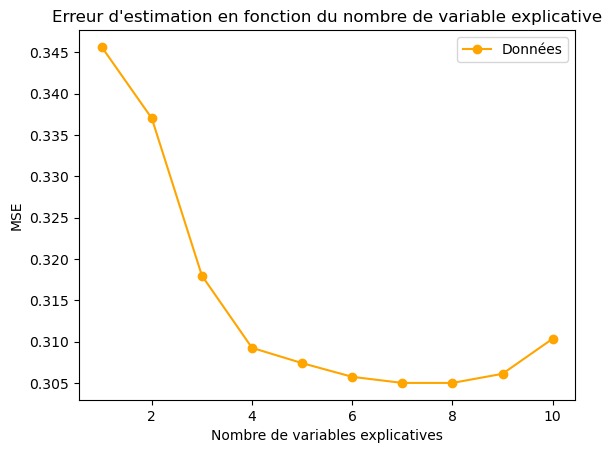

Le sous ensemble de variable explicative minimisant l'erreur de prédiction est : ('budget', 'runtime', 'main_genre_name_Drama', 'main_genre_name_Crime', 'main_genre_name_Animation', 'main_genre_name_Fantasy', 'main_genre_name_Family')


In [19]:
X=df.loc[:,~df.columns.isin(['id', 'vote_average'])]
X.head()
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42) #Cela garantit que la séparation sera toujours la même à chaque exécution du code, ce qui rend les résultats reproductibles.
a=[]
b=[]
c=[]
var_explicative = [x for x in var_explicative if x not in ['id', 'vote_average'] and x not in var_non_significative_au_niv_5]
for i in range(1,len(var_explicative)+1): 
    combinations_list = generate_combinations(var_explicative, i) 
    L=[]
    L_comb=[]
    for comb in combinations_list: 

        # Initialiser le modèle de régression linéaire
        model = LinearRegression()

        # Entraîner le modèle avec l'ensemble d'entraînement
        model.fit(X_train.loc[:,comb], Y_train)

        # Prédire les résultats sur l'ensemble de test
        Y_pred = model.predict(X_test.loc[:,comb])

        # Évaluer la performance du modèle
        mse = mean_squared_error(Y_test, Y_pred)
        L.append(mse)
        L_comb.append(comb)
    a.append(i)
    b.append(min(L))
    c.append(L_comb[L.index(min(L))])

# Créer un graphique avec une couleur personnalisée
plt.plot(a, b, color='orange', marker='o', linestyle='-', label='Données')  
# Ajouter des titres et des légendes
plt.title("Erreur d'estimation en fonction du nombre de variable explicative")
plt.xlabel("Nombre de variables explicatives")
plt.ylabel("MSE")
plt.legend()  # Affiche la légende

# Afficher le graphe
plt.show()
print("Le sous ensemble de variable explicative minimisant l'erreur de prédiction est :",c[b.index(min(b))])

On effectue donc cette regression

In [20]:
X=df.loc[:, c[b.index(min(b))] ]
Y=df[["vote_average"]]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3) # 70% de notre échantillon est utilisé pour estimer les coefs de la regression linéaire 

# Initialiser le modèle de régression linéaire
model = LinearRegression()

# Entraîner le modèle avec l'ensemble d'entraînement
model.fit(X_train, Y_train)

# Prédire les résultats sur l'ensemble de test
Y_pred = model.predict(X_test)

# Afficher les coefficients de la régression linéaire
print("Coefficients de la régression linéaire :", model.coef_)
print("Ordonnée à l'origine (intercept) :", model.intercept_)

# Évaluer la performance du modèle
mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Erreur quadratique moyenne (MSE) : {mse}")
print(f"Erreur absolue moyenne (MAE) : {mae}")
print(f"Score R2 : {r2}")

Coefficients de la régression linéaire : [[-2.98328198e-09  9.60018575e-03  3.14696143e-01  3.93975347e-01
   4.88876511e-01  3.75449926e-02  7.22606042e-02]]
Ordonnée à l'origine (intercept) : [6.46144644]
Erreur quadratique moyenne (MSE) : 0.30977921365360434
Erreur absolue moyenne (MAE) : 0.44870573436178773
Score R2 : 0.3286165821676522


On obtient une meilleure erreur que lors de la première régression

Attention : ces résultats sont potentiellement biaisés du fait que les films sélectionnées sont des films populaires avec de nombreux votes. Une étude plus approfondie avec une diversité plus grandes des films, c'est à dire avec des films ayant de très mauvaises notes et de très bonnes notes serait pertinente. Cependant l'API ne nous fournit que des films populaires rendant impossible ces ouvertures de recherches. Néanmoins nous pouvons noté que le nombre de vote n'est pas une variable significative au niveau 5%, résultat qui appuie la pertinence de notre étude et l'acceptation de ce potentiel biais. 

# III - Prédire le genre d'un film à l'aide de forêts aléatoires

Pour prédire le genre d'un film, une simple régression linéaire ne suffit pas. 

Nous l'avons vu, dans notre jeu de données précédent, les genres des films ne sont pas du tout également répartis. Pour entraîner nos modèles, nous avons intérêt à essayer d'avoir des données plus équilibrées. 
De plus, pour éviter certains biais comme ceux que l'on vient de mentionner, nous voudrions tirer des films au hasard sur l'ensemble de la base de données TMDB. 

Problème, l'API de TMDB n'offre pas la possibilité de tirer au hasard des films dans une certaine catégorie. En effet, pour obtenir une liste d'ids de films pour chaque genre, nous sommes obligés de classer ces films par une de leurs caractéristiques ce qui biaise immédiatement nos données. La meilleure solution que nous ayons trouvé pour résoudre ce problème est de profiter du manque de données sur le revenu des films, de trier en fonction du revenu croissant et de prendre les films avec plus de deux commentaires. Ce n'est pas 100% aléatoire mais ça s'en rapproche. 

On commence par récolter nos données

In [21]:
#Cela prend un peu de temps

#ids=td.get_balanced_movie_list(1, headers=td.headers) # on charge n page par catégorie, cela fait n*nb_catégories*nb_films_page=n*19*20 films
#df_temp=td.get_movies_info(ids,headers=td.headers)

En remplaçant 1 par 10 on obtient le fichier balancedmovies.

Comme précédemment, telles quelles les données sont nombreuses et pas toutes nécessaires. Pour la lisibilité on élimine certaines colones, et traite certaines données. Par ailleurs, on construit de variables "overview_count" et "title_count" qui comptent le nombre de caractère de "overview" et de "title".

In [22]:
df1=pd.read_csv("balancedmovies.csv")
df1=td.clean_data(df1)
df1.head(2)

,budget,id,overview,popularity,release_date,revenue,runtime,title,vote_average,vote_count,main_genre_id,main_genre_name,full_poster_path,overview_count,title_count,timestamp
0,0,1397347,Undisputed WWE Champion Cody Rhodes will go he...,4.625,2024-12-14,0,82,Saturday Night's Main Event XXXVII,7.1,4,28,Action,https://image.tmdb.org/t/p/original//cS90gS08N...,332,34,1734134400
1,0,1389147,"Secret agents Mike, Stan, and Chloé, tasked wi...",476.610,2024-11-28,0,120,SDI: Secret Department of Intervention,4.6,7,28,Action,https://image.tmdb.org/t/p/original//yE1UuFMX3...,509,38,1732752000


In [23]:
df1.describe()

,budget,id,popularity,release_date,revenue,runtime,vote_average,vote_count,main_genre_id,overview_count,title_count,timestamp
count,3.251000e+03,3.251000e+03,3251.000000,3211,3.251000e+03,3251.000000,3251.000000,3251.000000,3251.000000,3251.000000,3251.000000,3.251000e+03
mean,9.607084e+04,8.587139e+05,3.514555,2005-09-12 13:00:45.966988416,1.177484e+03,66.377115,5.910799,9.516456,3270.045832,258.409720,18.645647,9.991858e+08
min,0.000000e+00,2.526000e+03,0.000000,1878-05-07 00:00:00,0.000000e+00,0.000000,1.000000,2.000000,12.000000,1.000000,1.000000,-9.223372e+09
25%,0.000000e+00,5.320705e+05,0.532000,2000-01-01 00:00:00,0.000000e+00,17.000000,4.800000,2.000000,27.000000,139.000000,11.000000,8.782992e+08
50%,0.000000e+00,9.283330e+05,1.128000,2020-09-05 00:00:00,0.000000e+00,80.000000,6.000000,3.000000,53.000000,210.000000,16.000000,1.595894e+09
75%,0.000000e+00,1.186352e+06,2.455000,2023-09-05 12:00:00,0.000000e+00,95.000000,7.000000,5.000000,9648.000000,334.000000,24.000000,1.693483e+09
max,1.000000e+08,1.407762e+06,476.610000,2024-12-26 00:00:00,2.800000e+06,810.000000,10.000000,3340.000000,10770.000000,999.000000,109.000000,1.735171e+09
std,2.078201e+06,3.627284e+05,13.477362,NaN,5.214263e+04,47.105478,1.798761,67.027204,4791.309821,177.379016,11.055660,1.467448e+09


## A - Que donne une ACP sur le genre?

Avant de s'intéresser aux forêts aléatoires, on peut regarder si une ACP ne permet pas déjà de distinguer certains genres.

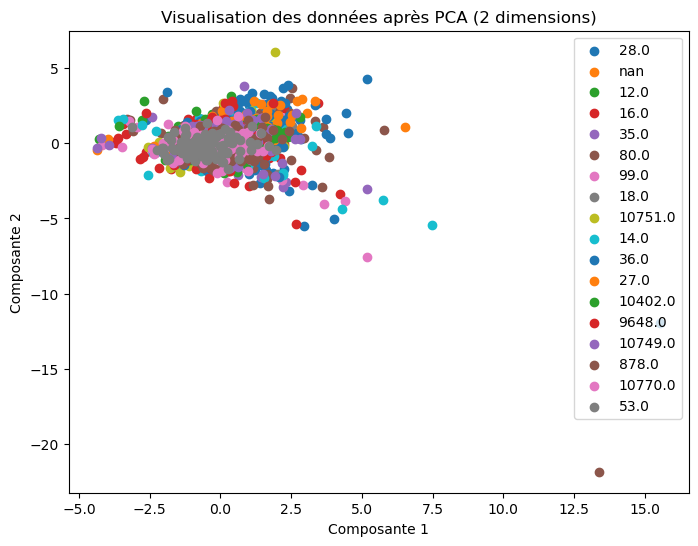

,Composante 1,Composante 2,classe
0,1.144472,1.156906,28.0
1,15.564669,-11.964552,28.0


In [24]:
dfacp= gp.genreacp(df1,2)
dfacp.head(2)

Globalement, pas grand chose d'évident. 

## B - Prédire le genre grâce à des Forêts Aléatoires

On va maintenant utiliser un modèle classique de Machine Learning pour prédire le genre: les forêts aléatoires. 

On commence par un modèle qui ne prend en compte que les données numériques

In [25]:
X=df1.drop(columns=['id','overview','release_date', 'title', 'main_genre_name', "full_poster_path", "main_genre_id"])
y=df1['main_genre_name']

rf_num_full=gp.rfnum(X,y, random_state=1)

Rapport de classification :
                 precision    recall  f1-score   support

         Action       0.28      0.24      0.25        34
      Adventure       0.25      0.26      0.25        39
      Animation       0.44      0.50      0.47        34
         Comedy       0.49      0.54      0.51        35
          Crime       0.16      0.11      0.13        36
    Documentary       0.38      0.50      0.43        26
          Drama       0.38      0.47      0.42        38
         Family       0.30      0.48      0.37        27
        Fantasy       0.14      0.07      0.10        42
        History       0.30      0.34      0.32        32
         Horror       0.36      0.26      0.30        39
          Music       0.55      0.46      0.50        35
        Mystery       0.14      0.09      0.11        35
        Romance       0.37      0.17      0.23        42
Science Fiction       0.22      0.35      0.27        31
       TV Movie       0.20      0.17      0.19        23
  

L'échantillon équilibré fait que le modèle essaye de prédire chaque genre. On observe une réelle différence de performance entre les différents genre. 

Dans ce modèle, la date est la variable qui contribue le plus de prédire le genre. Suivent ensuite la popularité et la longueur du film. Étonnamment, la longueur du titre et du synopsis aident tout autant à prédire le genre du film. 

On peut ensuite appliquer les forêts aléatoires à la matrice TF-IDF du synopsis des films. 

In [26]:
X = df1['overview']
y = df1['main_genre_name']

rf_nlp, vectorizer, label_encoder=gp.rfnlp(X,y, random_state=1)


Rapport de classification :
                 precision    recall  f1-score   support

         Action       0.22      0.15      0.18        34
      Adventure       0.41      0.23      0.30        39
      Animation       0.16      0.29      0.21        34
         Comedy       0.54      0.43      0.48        35
          Crime       0.27      0.22      0.24        36
    Documentary       0.30      0.27      0.29        26
          Drama       0.09      0.05      0.07        38
         Family       0.23      0.22      0.23        27
        Fantasy       0.04      0.02      0.03        42
        History       0.45      0.28      0.35        32
         Horror       0.35      0.38      0.37        39
          Music       0.64      0.80      0.71        35
        Mystery       0.18      0.17      0.18        35
        Romance       0.22      0.24      0.23        42
Science Fiction       0.27      0.45      0.34        31
       TV Movie       0.00      0.00      0.00        23
 

On a des résultats légèrement moins bons qu'avec les variables numériques. 

On peut voir pour chaque genre, quels mots permettent le mieux de le prédire:

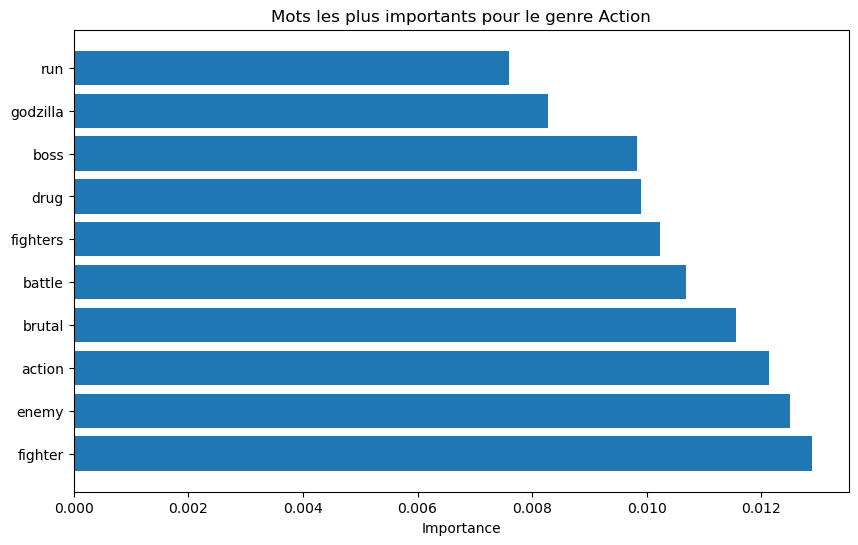

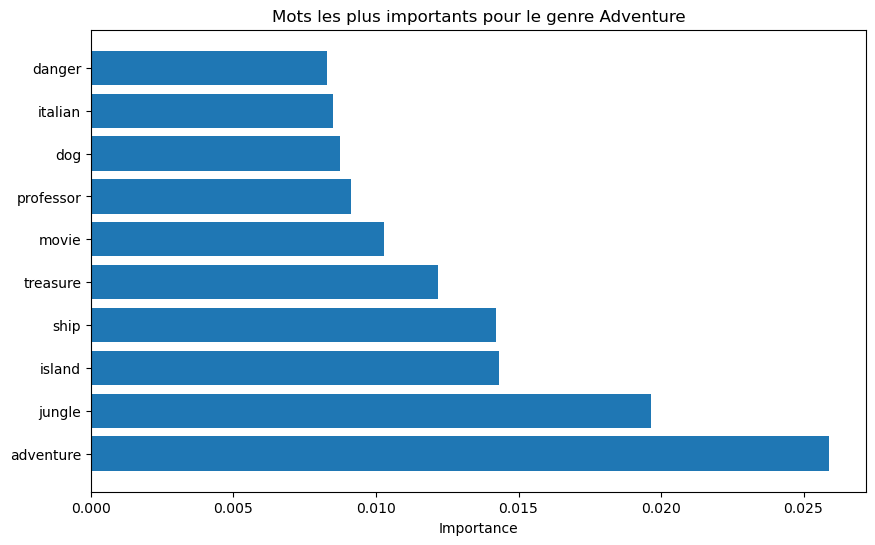

In [27]:
#Pour les voir tous:
# gp.plot_important_words_for_genre(range(len(rf_nlp.estimators_)), rf_nlp, vectorizer, label_encoder)

gp.plot_important_words_for_genre([0,1], rf_nlp, vectorizer, label_encoder)

Ces mots sont plutôt cohérents!

Enfin, grâce aux pipelines on peut combiner ces deux méthodes pour obtenir de bien meilleurs scores de précision!

In [28]:
gp.super_model(df1, random_state=1)


Rapport de classification :
                 precision    recall  f1-score   support

         Action       0.52      0.35      0.42        34
      Adventure       0.76      0.97      0.85        39
      Animation       0.61      0.82      0.70        34
         Comedy       0.79      0.54      0.64        35
          Crime       0.59      0.28      0.38        36
    Documentary       0.69      0.85      0.76        26
          Drama       0.61      0.71      0.66        38
         Family       0.49      0.63      0.55        27
        Fantasy       0.70      0.55      0.61        42
        History       0.53      0.56      0.55        32
         Horror       0.55      0.54      0.55        39
          Music       0.94      0.89      0.91        35
        Mystery       0.47      0.43      0.45        35
        Romance       0.62      0.55      0.58        42
Science Fiction       0.44      0.71      0.54        31
       TV Movie       1.00      0.13      0.23        23
 

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text', TfidfVectorizer(),
                                                  'overview'),
                                                 ('num', StandardScaler(),
                                                  Index(['budget', 'popularity', 'revenue', 'runtime', 'vote_average',
       'vote_count', 'main_genre_id', 'overview_count', 'title_count',
       'timestamp'],
      dtype='object'))])),
                ('classifier', RandomForestClassifier(random_state=1))])

# IV - L'influence du lieu de tournage sur les caractéristiques d'un film

Nous nous intéressons maintenant aux lieux de tournages des films à paris et cherchons à savoir si certains quartiers sont plus associés à certains genres.

## A - Création de la base de donnée commune

Pour cela nous changeons de nouveau de jeu de données et on importe depuis TMDB uniquement les données correspondant aux meilleurs films français sortis aux dates correspondantes à celles de la base de donnée des lieux de tournage à Paris

In [5]:
#importer les ids et les infos des films de tmdb en format csv

#ids= td.get_movie_ids_list_map(500, headers=td.headers)
#df=td.get_movies_info(ids,headers=td.headers)
#df.to_csv("data_tmdb_map.csv", sep=',', index=False, encoding='utf-8')


In [6]:
#lire la base de données 
df=pd.read_csv("data_tmdb_map.csv",sep=',')
df_tmdb=td.clean_data(df, False)

#convertir en minuscule la colonne original_title 
df_tmdb['original_title']=df_tmdb['original_title'].str.lower()
df_tmdb.tail(3)

,budget,id,original_title,overview,popularity,release_date,revenue,runtime,title,vote_average,vote_count,main_genre_id,main_genre_name,full_poster_path,overview_count,title_count,timestamp
9995,0,759430,blossom,"Engaged to the Nightingale, Rose will be ready...",0.655,2020-10-31,0,7,Blossom,4.0,1,27,Horror,https://image.tmdb.org/t/p/original//sD0XYqGkg...,93,7,1604102400
9996,0,692239,je parle à mes démons,Patrice is an inmate in the french prison Bois...,0.440,2020-10-31,0,24,I Speak To My Demons,0.0,0,99,Documentary,https://image.tmdb.org/t/p/original//vh02q3sJf...,185,20,1604102400
9998,0,1137853,revenge,"In love, a girl goes to join her ex-boyfriend ...",0.014,2020-11-01,0,14,Revenge,0.0,0,18,Drama,NaN,180,7,1604188800


In [ ]:
#importer la base de données des lieux de tournage parisiens

#lire la base de données de la ville de Paris
df_lieux=pd.read_csv("lieux-de-tournage-a-paris.csv",sep=';')

#filtrer la base de données pour ne retenir que les fomats en commun avec tmdb
df_lieux=df_lieux[df_lieux['Type de tournage'].isin(['Long métrage', 'Téléfilm'])]
print("Il y a " + str(df_lieux.shape[0]) + " films dans la base de données des lieux de tournage parisiens")
df_lieux.head(3)



Il y a 7897 films dans la base de données des lieux de tournage parisiens


,Identifiant du lieu,Année du tournage,Type de tournage,Titre,Réalisateur,Producteur,Localisation de la scène,Code postal,Date de début,Date de fin,Coordonnée en X,Coordonnée en Y,geo_shape,geo_point_2d
3,2019-535,2019,Long métrage,En attendant qui ? Mai,Marc RECUENCO,SerialBstudio,"rue léon droux, 75017 paris",75017.0,2019-06-10,2019-06-10,2.318919,48.882377,"{""coordinates"": [2.318919045887731, 48.8823773...","48.882377323745416, 2.318919045887731"
9,2019-1525,2019,Long métrage,Les Années 10 - L'infiltré,Thierry De Peretti,Les Films Velvet,"87 avenue de la grande armée, 75116 paris",75116.0,2019-11-07,2019-11-09,2.284072,48.876903,"{""coordinates"": [2.284072411245358, 48.8769031...","48.8769031427761, 2.284072411245358"
11,2018-912,2018,Long métrage,It Must Be Heaven,Elia Suleiman,Rectangle Productions,"passage de la canopée, 75001 paris",75001.0,2018-08-12,2018-08-12,2.346423,48.862158,"{""coordinates"": [2.346422664713688, 48.8621582...","48.86215827046971, 2.346422664713688"


In [8]:
#merge les deux bases de données sur le titre du film
df_lieux_renomme = df_lieux.rename(columns={'Titre': 'original_title'})
df_lieux_renomme['original_title'] = df_lieux_renomme['original_title'].str.lower()
df_merge = pd.merge(df_tmdb, df_lieux_renomme, how='inner', on='original_title')
df_merge.head(3)

,budget,id,original_title,overview,popularity,release_date,revenue,runtime,title,vote_average,...,Réalisateur,Producteur,Localisation de la scène,Code postal,Date de début,Date de fin,Coordonnée en X,Coordonnée en Y,geo_shape,geo_point_2d
0,0,504167,nadia,"Nadia raised, alone, her son Noé in Paris subu...",1.026,2016-02-10,0,89,Nadia,5.3,...,LEA MAZER,MURMURES PRODUCTIONS,49/49BIS BOULEVARD DE PICPUS,75012.0,2016-04-21,2016-04-21,2.401806,48.844582,"{""coordinates"": [2.401805999975272, 48.8445819...","48.84458199957575, 2.401805999975272"
1,0,504167,nadia,"Nadia raised, alone, her son Noé in Paris subu...",1.026,2016-02-10,0,89,Nadia,5.3,...,LEA MAZER,MURMURES PRODUCTIONS,146 RUE DU FAUBOURG POISSONNIERE,75009.0,2016-04-15,2016-04-15,2.349026,48.877580,"{""coordinates"": [2.349025999974713, 48.8775800...","48.87758000021916, 2.349025999974713"
2,0,504167,nadia,"Nadia raised, alone, her son Noé in Paris subu...",1.026,2016-02-10,0,89,Nadia,5.3,...,LEA MAZER,MURMURES PRODUCTIONS,67 BOULEVARD PICPUS,75012.0,2016-05-03,2016-05-03,2.399661,48.846623,"{""coordinates"": [2.3996610002713763, 48.846623...","48.84662300018563, 2.3996610002713763"


In [9]:
#afficher les films en commun entre les deux bases de données
films_communs=df_merge["original_title"].unique()
print("Il y a " + str(len(films_communs)) + " films en commun dans les deux bases de données")
films_communs

Il y a 179 films en commun dans les deux bases de données


array(['nadia', 'barbara', 'goliath', 'maman a tort',
       "vous n'aurez pas ma haine", 'la fille de brest', 'eva', 'dalida',
       "l'ascension", 'raid dingue', 'seuls', 'alibi.com',
       "l'embarras du choix", 'gangsterdam', 'la consolation',
       'corporate', 'bienvenue au gondwana', 'jour j',
       'je voulais juste rentrer chez moi', 'blockbuster',
       "l'amant d'un jour", 'les ex', 'bad buzz', 'le redoutable',
       'cherchez la femme', 'mon poussin', 'little jaffna', 'burn out',
       'une vie violente', 'lola pater', 'la douleur',
       '120 battements par minute', 'rodin', 'voir le jour',
       "l'un dans l'autre", 'les affamés', 'le petit spirou', 'coexister',
       'knock', 'jeune femme', 'carbone', "d'après une histoire vraie",
       'jalouse', 'maryline', 'simon et théodore', 'le brio', 'plonger',
       "c'est tout pour moi", 'la sainte famille', 'arthur rambo',
       'que le diable nous emporte', 'la bête', 'une saison en france',
       'les tuche 3', 

In [10]:
#package nécessaire 
import geopandas as gpd
from shapely.geometry import Point

#créer la colonne geometry avec des objets Point
geometry = [Point(xy) for xy in zip(df_merge["Coordonnée en X"], df_merge["Coordonnée en Y"])]

#convertir en GeoDataFrame
gdf_merge = gpd.GeoDataFrame(df_merge, geometry=geometry)

#définir le système de projection
gdf_merge.set_crs(epsg=4326, inplace=True)  # (système global utilisé pour les coordonnées GPS)

print(gdf_merge.head(3))

   budget      id original_title  \
0       0  504167          nadia   
1       0  504167          nadia   
2       0  504167          nadia   

                                            overview  popularity release_date  \
0  Nadia raised, alone, her son Noé in Paris subu...       1.026   2016-02-10   
1  Nadia raised, alone, her son Noé in Paris subu...       1.026   2016-02-10   
2  Nadia raised, alone, her son Noé in Paris subu...       1.026   2016-02-10   

   revenue  runtime  title  vote_average  ...            Producteur  \
0        0       89  Nadia           5.3  ...  MURMURES PRODUCTIONS   
1        0       89  Nadia           5.3  ...  MURMURES PRODUCTIONS   
2        0       89  Nadia           5.3  ...  MURMURES PRODUCTIONS   

             Localisation de la scène Code postal Date de début  Date de fin  \
0      49/49BIS  BOULEVARD  DE PICPUS     75012.0    2016-04-21   2016-04-21   
1  146  RUE  DU FAUBOURG POISSONNIERE     75009.0    2016-04-15   2016-04-15   
2    

In [11]:
#nettoyage de la base de données mergée

#filtrage des lignes selon leur geometry : longitude et latitude de Paris X: 2.33333 Y: 48.866669
#filtrage des lignes selon le code postal : le département de Paris est le 75
filtred_gdf_merge=gdf_merge[(gdf_merge['Coordonnée en X']>2) & (gdf_merge['Coordonnée en X']<3) & (gdf_merge['Coordonnée en Y']>48) & (gdf_merge['Coordonnée en Y']<49) & (gdf_merge['Code postal'].astype(str).str[:2] == '75')]
filtred_gdf_merge.geometry.describe()

count                               1942
unique                              1490
top       POINT (2.33872114 48.88585596)
freq                                  14
Name: geometry, dtype: object

In [12]:
#renommer l'index 75116 par 75016
filtred_gdf_merge['Code postal'] = filtred_gdf_merge['Code postal'].replace(75116.0, 75016.0)
print(filtred_gdf_merge['Code postal'].unique())


[75012. 75009. 75016. 75005. 75011. 75017. 75001. 75018. 75004. 75006.
 75020. 75007. 75013. 75002. 75008. 75014. 75015. 75019. 75010. 75003.]


/opt/conda/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


## B - Visualisation des données sur une carte

Un premier essai naïf permet d'avoir une idée d'où sont tournés les films

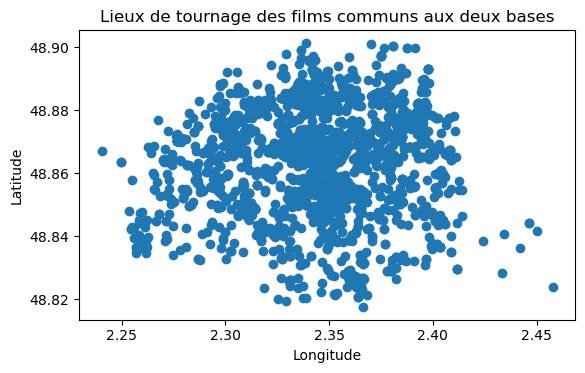

In [13]:
#visualiser les données sur une carte
import matplotlib.pyplot as plt
filtred_gdf_merge.plot()
plt.title('Lieux de tournage des films communs aux deux bases')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

Le but de cette première partie est d'améliorer ce graphique pour mieux comprendre la répartition spatiale des lieux de tournage parisiens communs aux deux bases de données. 

In [14]:
#compter le nombre d'observations par arrondissement
s_count = filtred_gdf_merge.groupby('Code postal').size()
df_count = s_count.to_frame()
print(df_count)


               0
Code postal     
75001.0       84
75002.0       72
75003.0       29
75004.0      127
75005.0       91
75006.0       57
75007.0      104
75008.0      122
75009.0      119
75010.0       96
75011.0      107
75012.0       99
75013.0       87
75014.0       47
75015.0       78
75016.0      144
75017.0       60
75018.0      162
75019.0      155
75020.0      102


In [15]:
#groupement par 'code postal' et calcul de la moyenne des coordonnées GPS
mean_x = filtred_gdf_merge.groupby('Code postal')['Coordonnée en X'].mean()
mean_y = filtred_gdf_merge.groupby('Code postal')['Coordonnée en Y'].mean()
df_mean_x = mean_x.to_frame()
df_mean_y = mean_y.to_frame()

print(df_mean_x)



             Coordonnée en X
Code postal                 
75001.0             2.338428
75002.0             2.343292
75003.0             2.358427
75004.0             2.355304
75005.0             2.349963
75006.0             2.334682
75007.0             2.311483
75008.0             2.310610
75009.0             2.338814
75010.0             2.359721
75011.0             2.377676
75012.0             2.396606
75013.0             2.363626
75014.0             2.329946
75015.0             2.299602
75016.0             2.275745
75017.0             2.308029
75018.0             2.342811
75019.0             2.385763
75020.0             2.396771


In [16]:
#ajouter des colonnes à df_mean_x afin d'améliorer la représentation cartographique

df_mean_x['Coordonnée en Y']=df_mean_y['Coordonnée en Y']
df_mean_x['Effectif']=df_count[0]

#Fréquences des lieux de tournage par arrondissement
effectif_total=df_mean_x['Effectif'].sum()
df_mean_x['Fréquence']=df_mean_x['Effectif']/effectif_total

#Rayons de cercles dont l'aire est proportionnelle à la fréquence par arrondisssement
alpha=0.003 #échelle
df_mean_x['Rayon']=np.sqrt((alpha*df_mean_x['Fréquence'])/np.pi)

print(df_mean_x)

             Coordonnée en X  Coordonnée en Y  Effectif  Fréquence     Rayon
Code postal                                                                 
75001.0             2.338428        48.862168        84   0.043254  0.006427
75002.0             2.343292        48.868115        72   0.037075  0.005950
75003.0             2.358427        48.864625        29   0.014933  0.003776
75004.0             2.355304        48.854490       127   0.065396  0.007902
75005.0             2.349963        48.846230        91   0.046859  0.006689
75006.0             2.334682        48.850862        57   0.029351  0.005294
75007.0             2.311483        48.854318       104   0.053553  0.007151
75008.0             2.310610        48.873552       122   0.062822  0.007745
75009.0             2.338814        48.877655       119   0.061277  0.007650
75010.0             2.359721        48.875103        96   0.049434  0.006871
75011.0             2.377676        48.860710       107   0.055098  0.007254

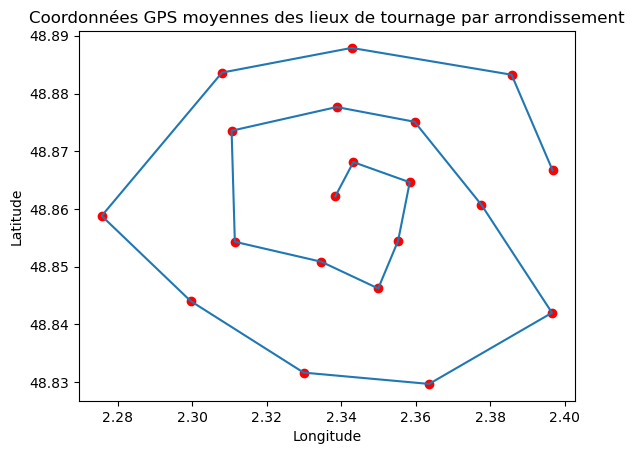

In [17]:
#visualiser les données sur une carte
plt.plot(df_mean_x['Coordonnée en X'],df_mean_y['Coordonnée en Y'])
plt.scatter(df_mean_x['Coordonnée en X'],df_mean_y['Coordonnée en Y'], color='red')
plt.title('Coordonnées GPS moyennes des lieux de tournage par arrondissement')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

En prenant la moyenne des coordonnées GPS par arrondissement, on retrouve bien l'emplacement approximatif de chaque arrondissement et la disposition "en escargot".

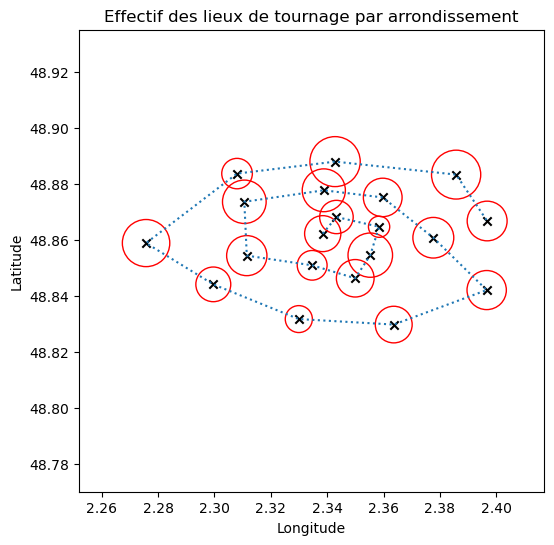

In [18]:
# Créer une figure et un axe
#fig, ax = plt.subplots()

# Ajouter un cercle
#circle = plt.Circle((0.5, 0.5), 0.3, color='red', fill=True)  # Cercle rempli
#ax.add_artist(circle)

# Ajuster les limites de l'axe
#ax.set_xlim(0, 1)
#ax.set_ylim(0, 1)
#ax.set_aspect('equal')



fig, ax = plt.subplots(figsize=(6, 6)) #format de la feuille carré de coté 6 pouces
ax.set_xlim(2.252, 2.417)
ax.set_ylim(48.77, 48.935)

#afficher les coordonnées moyennes des lieux de tournage par arrondissement
plt.scatter(df_mean_x['Coordonnée en X'],df_mean_y['Coordonnée en Y'], marker='x', color='k')

#les relier
plt.plot(df_mean_x['Coordonnée en X'],df_mean_y['Coordonnée en Y'], linestyle='dotted')


#afficher des cercles dont le rayon correspond à l'effectif par arrondissement
for code_postal in filtred_gdf_merge['Code postal'].unique():
    circle= plt.Circle((df_mean_x['Coordonnée en X'].loc[code_postal], 
    df_mean_x['Coordonnée en Y'].loc[code_postal]), 
    df_mean_x['Rayon'].loc[code_postal], 
    color='red', fill=False)  # Cercle rempli
    ax.add_artist(circle)

plt.title('Effectif des lieux de tournage par arrondissement')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [19]:
#packages necessaires
!pip install pandas fiona shapely pyproj rtree 
!pip install contextily
!pip install geopandas
!pip install topojson

# # Cartiflette:
!pip install py7zr geopandas openpyxl tqdm s3fs
!pip install PyYAML xlrd
!pip install git+https://github.com/inseefrlab/cartiflette


!pip install --upgrade urllib3
!pip install --upgrade cartiflette
import contextily as ctx
import matplotlib.pyplot as plt
from cartiflette import carti_download

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.2/543.2 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 84.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 96.3 MB/s eta 0:00:00
  Cloning https://github.com/inseefrlab/cartiflette to /tmp/pip-req-build-6wubiehh
  Running command git clone --filter=blob:none --quiet https://github.com/inseefrlab/cartiflette /tmp/pip-req-build-6wubiehh
  Resolved https://github.com/inseefrlab/cartiflette to commit f6b0c5d049bd6dcae7b437bd931957371da24278
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 90.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 102.1 MB/s

In [20]:
#importer les données des bordures des arrondissements
from cartiflette import carti_download

arrondissement_borders = carti_download(
    crs=4326,
    values=["75"],
    borders="COMMUNE_ARRONDISSEMENT",
    vectorfile_format="geojson",
    filter_by="DEPARTEMENT",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022,
)

print(arrondissement_borders.head(3))

  INSEE_DEP  INSEE_REG                        ID                      NOM  \
0        75         11  ARR_MUNI0000000009736045  Paris 3e Arrondissement   
1        75         11  ARR_MUNI0000000009736046  Paris 2e Arrondissement   
2        75         11  ARR_MUNI0000000009736545  Paris 4e Arrondissement   

  INSEE_COM                    STATUT  POPULATION INSEE_COG  ARR    CV  ...  \
0     75056  Arrondissement municipal       34025     75103  751  75ZZ  ...   
1     75056  Arrondissement municipal       21595     75102  751  75ZZ  ...   
2     75056  Arrondissement municipal       29131     75104  751  75ZZ  ...   

  AAV2020 TAAV2017  TDAAV2017 CATEAAV2020  BV2012  LIBELLE_DEPARTEMENT  \
0     001        5         50          11   75056                Paris   
1     001        5         50          11   75056                Paris   
2     001        5         50          11   75056                Paris   

  LIBELLE_REGION    PAYS                            SOURCE  \
0  Île-de-Franc

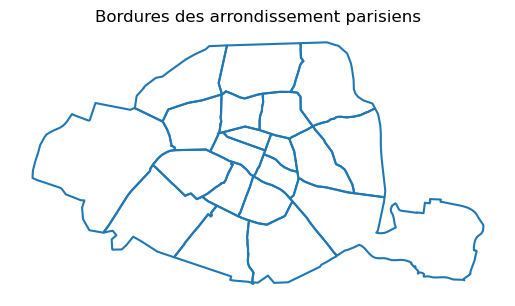

In [21]:
#afficher les bordures des arrondissements
base = arrondissement_borders.boundary.plot()


plt.plot(ax=base)
base.set_title('Bordures des arrondissement parisiens')
base.set_axis_off()

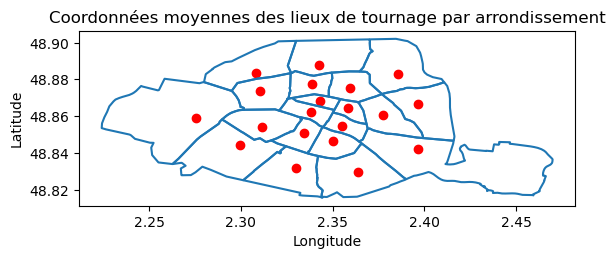

In [22]:
#afficher les données sur les lieux de tournage parisiens avec le fond de carte

df_coord=df_mean_x.loc[:, ['Coordonnée en X','Coordonnée en Y']]

#conversion en geodataframe

#créer la colonne geometry avec des objets Point
geometry = [Point(xy) for xy in zip(df_coord["Coordonnée en X"], df_coord["Coordonnée en Y"])]

#convertir en GeoDataFrame
gdf_coord = gpd.GeoDataFrame(df_coord, geometry=geometry)

#définir le système de projection
gdf_coord.set_crs(epsg=2154, inplace=True)

#afficher le fond de carte
base = arrondissement_borders.boundary.plot()

#afficher les coordonnées moyennes des lieux de tournage par arrondissement
gdf_coord.plot(ax=base,color='red')

plt.title('Coordonnées moyennes des lieux de tournage par arrondissement')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


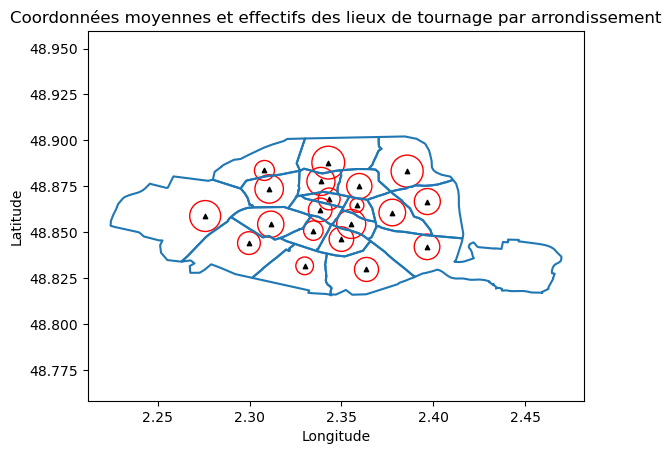

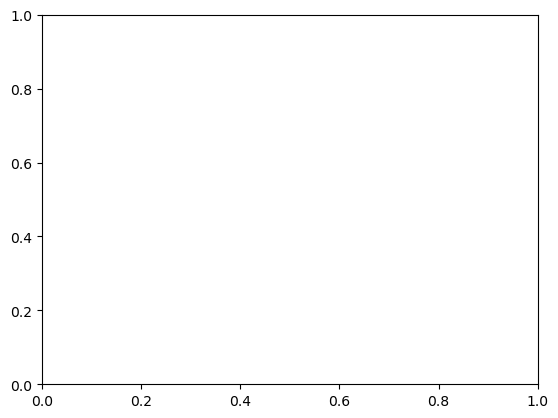

In [23]:
base = arrondissement_borders.boundary.plot()

#créer un graphique
fig, ax = plt.subplots()
ax=base
ax.axis('equal')

#afficher les coordonnées moyennes des lieux de tournage par arrondissement
gdf_coord.plot(ax=base,color='k',marker='^',markersize=10)

#afficher des cercles dont le rayon correspond à l'effectif par arrondissement
for code_postal in filtred_gdf_merge['Code postal'].unique():
    circle= plt.Circle((df_mean_x['Coordonnée en X'].loc[code_postal], 
    df_mean_x['Coordonnée en Y'].loc[code_postal]), 
    df_mean_x['Rayon'].loc[code_postal], 
    color='red', fill=False) 
    ax.add_artist(circle)
ax.set_title('Coordonnées moyennes et effectifs des lieux de tournage par arrondissement')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

Les lieux de tournage sont globalement répartis sur l'ensemble du territoire de chaque arrondissement, les triangles noirs se situant en général au milieu de chaque arrondissement. On relève néanmoins quelques exceptions comme autour de la butte Montmartre. En effet, elle se situe entre le 10 et le 18ème arrondissement et on remarque que les triangles noirs sont excentrés du côté de Montmartre pour ces deux arrondissements. A l'inverse, la position des triangles noirs de 12 et du 16ème arrondissement indique que très peu de films sont tournés dans les bois de Paris.

Il n'est pas observé de tendance particulière en ce qui concerne la distribution des lieux de tournage entre arrondissements. On peut faire l'hypothèse que cette distribution dépend positivement de la présence de monuments et de studios d'enregistrement. Comme les premiers se situent en général au centre de Paris, tandis que les second se trouvent plutôt en périphérie, cela répartit les lieux de tournage sur l'ensemble du territoire parisien.

## C - Genres majoritaires dans chaque quartier de Paris

On veut maintenant représneter les genres majoriatires dans les différents quartiers de Paris

In [24]:
#compter les effectifs par genre dans les lieux de tournage
count_genre=df_tmdb.groupby('main_genre_name').size()
df_count_genre = count_genre.to_frame()
print(df_count_genre)

                    0
main_genre_name      
Action             23
Adventure          32
Animation         462
Comedy            734
Crime              52
Documentary      1626
Drama            1350
Family             17
Fantasy            64
History            27
Horror            100
Music              81
Mystery            33
Romance            67
Science Fiction    50
TV Movie           31
Thriller           80
War                10
Western             7


In [25]:
#compter les effectifs par genre dans la base de données une fois mergée
count_genre=filtred_gdf_merge.groupby('main_genre_name').size()
df_count_genre = count_genre.to_frame()
print(df_count_genre)


                   0
main_genre_name     
Action            33
Comedy           994
Crime             20
Documentary       38
Drama            606
Fantasy            5
History           14
Horror            40
Music             23
Mystery           24
Romance           48
Science Fiction   16
TV Movie          47
Thriller          34


Dans la base de données mergée, on remarque que les genres 'Comedy' et 'Drama' sont largement majoritaires, tandis que les genres 'Documentary' et 'Animation' sont absents ou beaucoup moins fréquents par rapport à tmdb. 
En effet, les films d'animation ne nécessitent pas de lieu de tournage déclaré en mairie, c'est pourquoi ils ne sont pas présents dans la base de données des tournages parisiens. Concernant les documentaires, on peut faire l'hypothèse que ceux-ci sont plus souvent tournés en province qu'à Paris, d'où leur moindre fréquence parmi les lieux de tournage parisiens.

In [26]:
#filtrer la base de données mergée pour enlever les genres les moins fréquents
filtred_gdf_merge=filtred_gdf_merge[filtred_gdf_merge['main_genre_name'].isin(['Comedy', 'Drama','Action','Documentary','Horror' ,'Music' ,'Mystery','Romance','TV Movie','Thriller'])]
print(filtred_gdf_merge['main_genre_name'])

0       TV Movie
1       TV Movie
2       TV Movie
3       TV Movie
4       TV Movie
          ...   
2002       Drama
2003       Drama
2004       Drama
2005       Drama
2006       Drama
Name: main_genre_name, Length: 1887, dtype: object


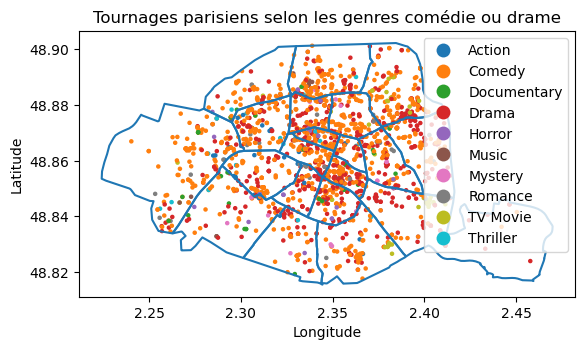

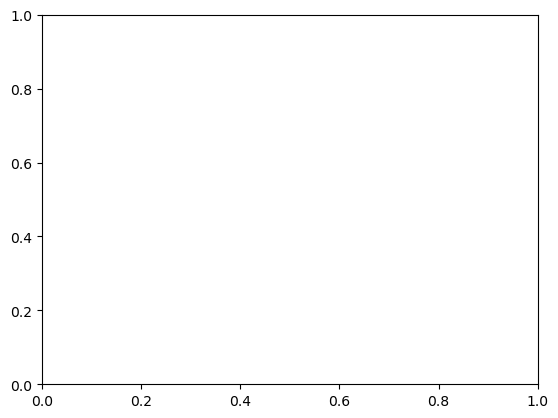

In [27]:
#afficher un fond de carte représentant les arrondissements parisiens
base = arrondissement_borders.boundary.plot()

#créer un nuage de points colorié en fonction du "genre"
fig, ax = plt.subplots()
ax=base
filtred_gdf_merge.plot(
    ax=ax,
    column='main_genre_name', #colonne pour colorier les points
    categorical=True, #couleurs distinctes
    legend=True,
    markersize=5,
)

ax.set_title('Tournages parisiens selon les genres comédie ou drame')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()


Pour chaque arrondissement, on va chercher à afficher sur la carte le poids du genre majoritaire parmi les autres genres.

In [28]:
#calcul des effectifs par arrondissement
count_total= filtred_gdf_merge.groupby('Code postal').size() #total
count_drama = filtred_gdf_merge.groupby('Code postal')['main_genre_name'].apply(lambda col: (col == 'Drama').sum()) #drame
count_comedy = filtred_gdf_merge.groupby('Code postal')['main_genre_name'].apply(lambda col: (col == 'Comedy').sum()) #comedy

#conversion en dataframe
df_count_total = count_total.to_frame()
df_count_drama = count_drama.to_frame()
df_count_comedy= count_comedy.to_frame()

print('nombre de tournage par arrondissement :')
print(df_count_total.head(3))
print('nombre de drames par arrondissement :')
print(df_count_drama.head(3))
print('nombre de comédies par arrondissement :')
print(df_count_comedy.head(3))



nombre de tournage par arrondissement :
              0
Code postal    
75001.0      82
75002.0      69
75003.0      27
nombre de drames par arrondissement :
             main_genre_name
Code postal                 
75001.0                   30
75002.0                   21
75003.0                   10
nombre de comédies par arrondissement :
             main_genre_name
Code postal                 
75001.0                   43
75002.0                   36
75003.0                   13


In [29]:
#construction des annotations pour la carte
annotations=[]
drama_majoritaire=[]

for code_postal in filtred_gdf_merge['Code postal'].unique():
    #calcul du pourcentage du poids du genre majoritaire parmi les autres genres
    pourcentage=max(df_count_drama['main_genre_name'].loc[code_postal], df_count_comedy['main_genre_name'].loc[code_postal])/df_count_total[0].loc[code_postal]*100
    pourcentage_affiche = f"{pourcentage:.1f}%"

    #les annotations contiennent les coordonnées et le pourcentage à afficher pour chaque arrondissement
    annotations = annotations + [[df_mean_x['Coordonnée en X'].loc[code_postal],df_mean_y['Coordonnée en Y'].loc[code_postal],pourcentage_affiche]]

    #créer une liste de boolean qui indique pour chaque arrondissement si les drames sont majoritaires par rapport aux comédies
    drama_majoritaire = drama_majoritaire + [df_count_drama['main_genre_name'].loc[code_postal]>=df_count_comedy['main_genre_name'].loc[code_postal]]

print(drama_majoritaire)
print('les coordonnées et le pourcentage pour le 1er arrondissement sont respectivement '+ str(annotations[0]))

[np.True_, np.False_, np.False_, np.True_, np.False_, np.False_, np.False_, np.False_, np.False_, np.True_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_]
les coordonnées et le pourcentage pour le 1er arrondissement sont respectivement [np.float64(2.39660629010101), np.float64(48.84201954434343), '46.9%']


In [32]:
#ajout des annoations
for x, y, etiquette in annotations:

    ax.text(
        x, y, etiquette, 
        fontsize=6, color=c[int(drama_majoritaire[i])], 
        ha='right', va='bottom',  # Alignement horizontal et vertical
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='k')  # Fond du texte
    )
    i=i+1
    

ax.set_title('Les genres majoritaires des tournages parisiens par arrondissement')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()

NameError: name 'c' is not defined

Ces résultats découlent directement de la prédominance des comédies par rapport aux drames dans la base de données mergée. On voit néanmoins que les drames sont plus nombreux que les comédies pour les arrondissements 5, 6 et 12, où il y a respectivement 46.1 %, 51.8 % et 46.9 % de drame parmi les lieux de tournage. L'objectif va être maintenant d'obtenir des ratios comparables en pondérant les effectifs de comédies ou de drames dans chaque arrondissement par les effectifs totaux de comédies ou de drames dans le jeu de données.

In [ ]:
#compter les effectifs totaux pour les genres comédie et drame
effectif_total_comedy=df_count_genre.loc['Comedy',0]
effectif_total_drama=df_count_genre.loc['Drama',0]

print('le nombre de comédies dans la base de données mergée est : ' + str(effectif_total_comedy))
print('le nombre de drames dans la base de données mergée est : ' + str(effectif_total_drama))

le nombre de comédies dans la base de données mergée est : 994
le nombre de drames dans la base de données mergée est : 606


In [ ]:
#construction des annotations pour la carte
annotations=[]
drama_majoritaire=[]

for code_postal in filtred_gdf_merge['Code postal'].unique():
    #calcul du pourcentage du poids du genre majoritaire parmi les autres genres
    pourcentage=max(df_count_drama['main_genre_name'].loc[code_postal]/effectif_total_drama, df_count_comedy['main_genre_name'].loc[code_postal]/effectif_total_comedy)*100
    pourcentage_affiche = f"{pourcentage:.1f}%"

    #les annotations contiennent les coordonnées et le pourcentage à afficher pour chaque arrondissement
    annotations = annotations + [[df_mean_x['Coordonnée en X'].loc[code_postal],df_mean_y['Coordonnée en Y'].loc[code_postal],pourcentage_affiche]]

    #créer une liste de boolean qui indique pour chaque arrondissement si les drames sont majoritaires par rapport aux comédies
    drama_majoritaire = drama_majoritaire + [df_count_drama['main_genre_name'].loc[code_postal]/effectif_total_drama>=df_count_comedy['main_genre_name'].loc[code_postal]/effectif_total_comedy]

print(drama_majoritaire)
print('les coordonnées et le pourcentage pour le 1er arrondissement sont respectivement '+ str(annotations[0]))

[np.True_, np.True_, np.False_, np.True_, np.True_, np.False_, np.True_, np.False_, np.True_, np.True_, np.True_, np.False_, np.False_, np.False_, np.False_, np.True_, np.True_, np.True_, np.False_, np.True_]
les coordonnées et le pourcentage pour le 1er arrondissement sont respectivement [np.float64(2.39660629010101), np.float64(48.84201954434343), '7.4%']


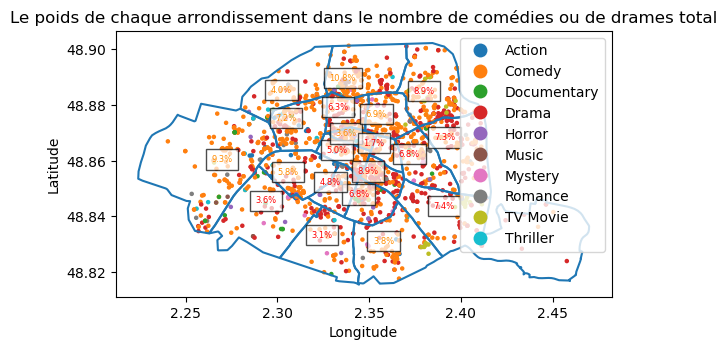

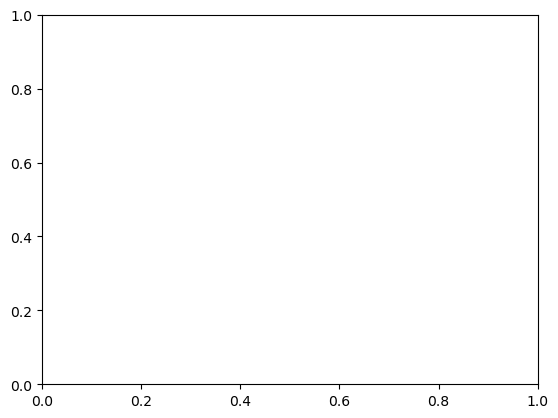

In [ ]:
base = arrondissement_borders.boundary.plot()

#créer un nuage de points colorié en fonction du "genre"
fig, ax = plt.subplots()
ax=base
filtred_gdf_merge.plot(
    ax=ax,
    column='main_genre_name', #colonne pour colorier les points
    categorical=True, #couleurs distinctes
    legend=True,
    markersize=5,
)

#vecteur des couleurs des points 
c=['darkorange','red']

i=0
#ajout des annoations
for x, y, etiquette in annotations:

    ax.text(
        x, y, etiquette, 
        fontsize=6, color=c[int(drama_majoritaire[i])], 
        ha='right', va='bottom',  # Alignement horizontal et vertical
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='k')  # Fond du texte
    )
    i=i+1
    

ax.set_title('Le poids de chaque arrondissement dans le nombre de comédies ou de drames total')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()

Cette représentation cartographique permet de mettre en lumière quels arrondissements contribuent le moins au nombre de comédies et de drames : ce sont les arrondissements dans le sud de Paris. Ils représentent au maximum environ 3 % des comédies ou les drames. 
La répartition des arrondissements qui contribuent le plus aux genres comedie et drame est plus ou moins uniforme.